<img align="center" src="https://iili.io/3wI8gI.png" style="height:90px" style="width:30px"/>

# Lab: Mobile Games Bayesian A/B Testing - Cookie Cats 
<img align="center" src="https://i.ytimg.com/vi/LkvnfULq8yQ/maxresdefault.jpg" style="height:400px" style="width:150px"/>

## Introduction
- The data we have is from 90,189 players that installed the game while the AB-test was running. 
- The variables are:
    -  `userid `: A unique number that identifies each player.
    -  `version `: Whether the player was put in the control group (gate30 - a gate at level 30) or <br>
    the group with the moved gate (gate40 - a gate at level 40).
    -  `sumgamerounds `: the number of game rounds played by the player during the first 14 days after install.
    -  `retention1 `: Did the player come back and play 1 day after installing?
    -  `retention_7 `: Did the player come back and play 7 days after installing?


This dataset includes A/B test results of Cookie Cats to examine what happens <br>
when the first gate in the game was moved from level 40 to level 30. <br> 
When a player installed the game, he or she was randomly assigned to either gate30 or gate40. <br> 

## Historical information
The retention rate for day 7 before the test is run was __18 %__, which in this Bayesian A/B test is what we will use as a basis for setting our prior belief and creating a prior distribution for the variable `retention_7 `

## Purpose of the project
__The purpose of the test is to see if changing the gate from level 40 to level 30 statistically increases the retention rate for day 7 (our KPI of interest).__ <br>  

The higher the retention rate, the better for the game. The gate has previously been at level 40. <br> 

Thus the experiment version, version B is called gate_30 and the control version A is gate_40 in the dataset 
<br>
### 1. Importing libraries and read the file `cookie_cats.csv`

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pymc as pm
import pandas as pd 

In [3]:
df = pd.read_csv("cookie_cats.csv")

### 2. Get the overview of the data

In [4]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


### 3  Set prior_alpha and prior_beta
- Based on the past experience the conversion rate is around __18%__<br>
- prior_alpha = 20
- prior_beta = 90
<br>
<br>
This representing our prior belief about the retention rate before seeing the data. <br>
Remember that setting a prior is subjective and there is no scientific basis for setting it. <br>
Here we are representing our belief with a distribution (a beta distribution in this case). <br>
Here we are providing you with a prior distribution with values for alpha and beta which work <br>
as degrees of certainty in what the most likely retention rate is, before seeing any data. <br>
The historical retention rate is 18 % why we are using a beta (20, 90) distribution which also indicates a pratty confident prior belief<br>
about the retention rate being around 18 % before changing anything in the app. <br>
In the bonus question, you'll be able to create your own prior distribution with other values for alpha <br>
and beta too see how representing your belief in different ways affects the results of the A/B test.  
<br>
<br>


In [5]:
# run this cell
prior_alpha = 20
prior_beta = 90

### 4. Visualize the retention rate of `Gate30` and `Gate40` in  day7
- Choose a chart you think you can show the information the best

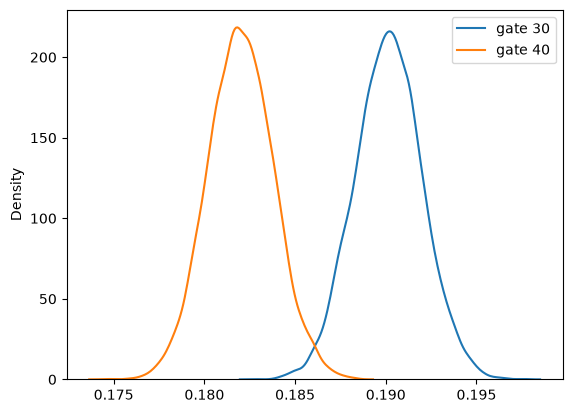

In [10]:
gate30_post_7days = np.random.beta(prior_alpha + len(df.loc[(df["version"] == "gate_30") & (df["retention_7"])]),
                                  prior_beta + len(df.loc[(df["version"] == "gate_30") & ~(df["retention_7"])]),
                                  10000)
gate40_post_7days = np.random.beta(prior_alpha + len(df.loc[(df["version"] == "gate_40") & (df["retention_7"])]),
                                  prior_beta + len(df.loc[(df["version"] == "gate_40") & ~(df["retention_7"])]),
                                  10000)

sns.kdeplot(gate30_post_7days, label="gate 30")
sns.kdeplot(gate40_post_7days, label="gate 40")
plt.legend()
plt.show()


### 5 Now you want to check which version has a better retention rate on day 7
#### Q1 Before you do any test based on the data which version shows a better retention rate?

In [ ]:
#gate 30 

SyntaxError: invalid syntax (81157025.py, line 1)

#### Q2 - Is this difference statistically different? Let's check it out
__Prepare the data__
1. Calculate result from `gate30` <br>
First calculate no. of conversions and save in a variable named `gate30_true`  <br>
Then calculate no. of non-conversions and save in a variable named `gate30_false`  <br>


2. Calculate result from `gate40`<br>
First calculate no. of conversions and save in a variable named `gate40_true`<br>
Then calculate no. of non-conversions and save in a variable named `gate40_false`<br>

#### Q3 simulating distributions

__(1) simulating the posterior distribution for `gate30` with a 10 000 sample size__ <br>

Draw 10 000 samples using the np.random.beta function from the following beta distribution: <br>
beta(prior_alpha + gate30_true, prior_beta + gate30_false) <br>
Save the sampled distribution in a variable name `gate30_posterior` <br>

__(2) simulating the posterior distribution for `gate40` with a 10000 sample size__<br>
Draw 10 000 samples using the np.random.beta function from the following beta distribution: <br>
beta(prior_alpha + gate40_true, prior_beta + gate40_false) <br>
Save the sampled distribution in a variable name `gate40_posterior` <br>


__(3) Visualize the distributions for:__ <br>
     </t>   1.  the posterior distribution for gate30 <br>
        2.  the posterior distribution for gate40 <br>
        3.  the prior distribution (Beta (20,90)) <br>

#### Q6 Now you have the distribution for both gate30 and gate40
- Calculate probability of gate30 being better than gate40

This can easily be done by:
- First, subtracting `gate30_posterior` from `gate40_posterior` (save this in a variable named `diff`)
- Then, calculate the percentage of times that the difference is less than 0
- If `gate_30 posterior` "beats" `gate_40 posterior` in more than 95 % of the cases (of the 10k samples drawn from both distributions) <br>
then we will change the gate in the app from 40 to 30, thus concluding that variant B has beaten variant A (control). 

In [11]:
diff = gate30_post_7days - gate40_post_7days
(diff > 0).mean()*100

np.float64(99.91)

#### Q7 Which version do you choose?
Answer question in text. Briefly explain your choice

In [ ]:
# What is the probability that gate30 "beats" gate40?
#99.91%

# How much gate30 is better than gate40 on average based on the 10k simulations? 
#less than 1%

# Therefore which version will you choose to increase the retention rate on day 7?
#yes barely

In [13]:
(gate30_post_7days.mean()) - (gate40_post_7days.mean())

np.float64(0.008139173896956425)

### Good job!
# Bonus
#### Now let's use Bayes A/B test to compare the performance of gate30 and gate40 in the retention rate on day 1!
- The retention rate for day 1 before the test is run was __44 %__, which in this Bayesian A/B test is what we will use as a basis for setting our prior belief and creating a prior distribution for the variable retention_1

#### Q1 Usa a beta distribution with alpha_prior and beta_prior based on the historical data of the retention rate 44 % to quantify your prior belief before seeing any new data
<br>
This representing our prior belief about the retention rate before seeing the data.
Remember that setting a prior is subjective and there is no scientific basis for setting it.
Here we are representing our belief with a distribution (a beta distribution in this case).
Here we are providing you with a prior distribution with values for alpha and beta which work
as degrees of certainty in what the most likely retention rate is, before seeing any data.
<br>

- You can use this website to decide your alpha_prior and beta-prior: <br>
https://homepage.divms.uiowa.edu/~mbognar/applets/beta.html

In [16]:
prior_alpha_1  = 72
prior_beta_1 = 90

#### Q2 Visualize the retention rate of two versions for day 1 

#### Q3 simulating distributions

#### `gate30`
- __Calculate result from gate30:__ calculate no. of conversions and non-conversion save in a variable named `gate30_true` and named `gate30_false`

- __Simulating the posterior distribution for `gate30` with a 10 000 sample size:__ Save the sampled distribution in a variable name `gate30_posterior` <br>

#### `gate40`
- __Calculate result from gate30:__ calculate no. of conversions and non-conversion save in a variable named `gate40_true` and named `gate40_false`

- __Simulating the posterior distribution for `gate40` with a 10 000 sample size:__ Save the sampled distribution in a variable name `gate40_posterior` <br>

#### Q4 Visualizing the distributions

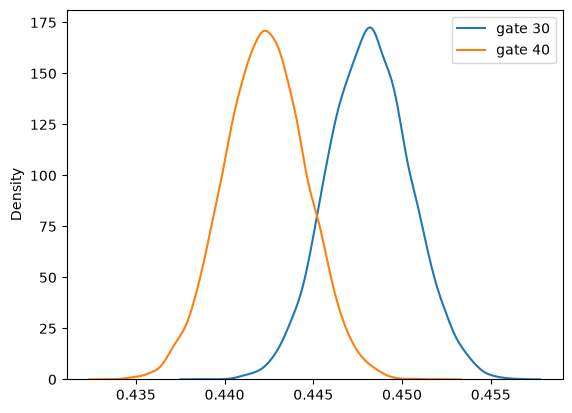

In [17]:
gate30_post_1day = np.random.beta(prior_alpha_1 + len(df.loc[(df["version"] == "gate_30") & (df["retention_1"])]),
                                  prior_beta_1 + len(df.loc[(df["version"] == "gate_30") & ~(df["retention_1"])]),
                                  10000)
gate40_post_1day = np.random.beta(prior_alpha_1 + len(df.loc[(df["version"] == "gate_40") & (df["retention_1"])]),
                                  prior_beta_1 + len(df.loc[(df["version"] == "gate_40") & ~(df["retention_1"])]),
                                  10000)

sns.kdeplot(gate30_post_1day, label="gate 30")
sns.kdeplot(gate40_post_1day, label="gate 40")
plt.legend()
plt.show()

#### Q5 Now you have the distribution for both gate30 and gate40
- Calculate probability of gate30 being better than gate40

In [ ]:
diff_1_day = gate30_post_1day - gate40_post_1day
(diff_1_day > 0).mean()*100

np.float64(96.23)

In [19]:
gate30_post_1day.mean() - gate40_post_1day.mean()

np.float64(0.0058661126495936355)

#### Q6 Draw a conclusion

In [ ]:
# What is the probability that gate30 "beats" gate40?
#96%
#  
# How much gate30 is better than gate40 on average based on the 10k simulations? 
#0.5%
#
# Therefore which version will you choose to increase the retention rate on day 1?
#gate 30

# Finish! Good job